In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [176]:
data = pd.read_csv('Video_Games.csv')
data

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
print(data.head())

                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24           NaN   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00         31.37           NaN   

   Critic_Count User_Score  User_Count Developer Rating 

In [178]:
# Checking for missing values in the dataset
print("\nMissing values before cleaning:")
print(data.isnull().sum())


Missing values before cleaning:
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64


In [179]:
# Dropping rows with missing values in 'Name', 'Genre', and 'Publisher'
data = data.dropna(subset=['Name', 'Genre', 'Publisher'])

# Filling missing 'Year_of_Release' with a placeholder (-1)
data.loc[:, 'Year_of_Release'] = data['Year_of_Release'].fillna(-1)

# Handling missing scores: Convert 'User_Score' to numeric 
data.loc[:, 'User_Score'] = pd.to_numeric(data['User_Score'], errors='coerce')

# Filling missing 'Critic_Score' and 'User_Score' with their respective medians
data.loc[:, 'Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].median())
data.loc[:, 'User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

# Filling missing 'Critic_Count' and 'User_Count' with their respective medians
data.loc[:, 'Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].median())
data.loc[:, 'User_Count'] = data['User_Count'].fillna(data['User_Count'].median())

/var/folders/pr/dq7r5k250_b6mj846ln15zsr0000gn/T/ipykernel_31676/2747503230.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.loc[:, 'User_Score'] = data['User_Score'].fillna(data['User_Score'].median())


In [180]:
# Filling missing 'Developer' and 'Rating' with 'Unknown'
data.loc[:, 'Developer'] = data['Developer'].fillna('Unknown')
data.loc[:, 'Rating'] = data['Rating'].fillna('Unknown')

# Re-checking for missing values after cleaning
print("\nMissing values after cleaning:")
print(data.isnull().sum())



Missing values after cleaning:
Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64


In [181]:
# Renaming columns for better readability
data.rename(columns={'Price': '$Price'}, inplace=True)

# Displaying the first few rows after cleaning
print("\nDataset after cleaning:")
print(data.head())



Dataset after cleaning:
                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24          71.0   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00         31.37          71.0   

   Critic_Count User_Score  Use

/var/folders/pr/dq7r5k250_b6mj846ln15zsr0000gn/T/ipykernel_31676/823763868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns={'Price': '$Price'}, inplace=True)


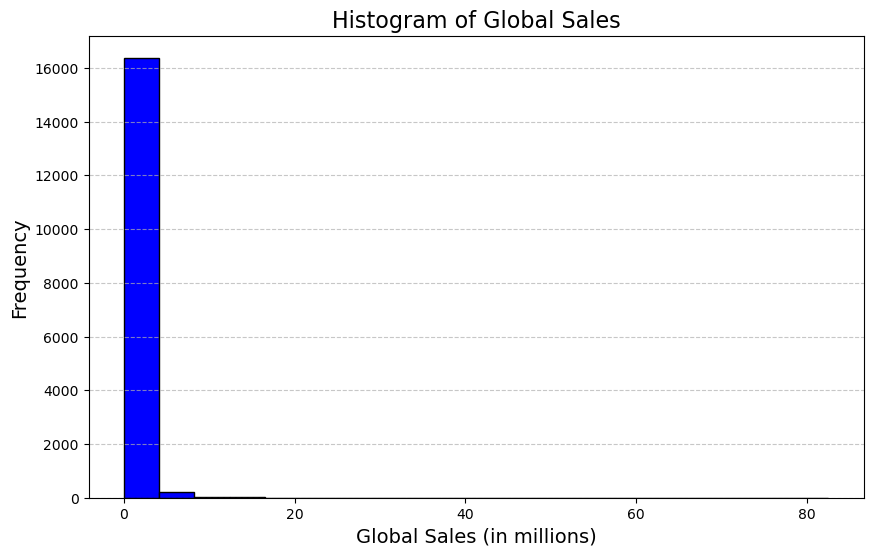

In [182]:
# Exploratory Data Analysis: Plotting histogram of global sales
plt.figure(figsize=(10, 6))
plt.hist(data['Global_Sales'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Global Sales', fontsize=16)
plt.xlabel('Global Sales (in millions)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


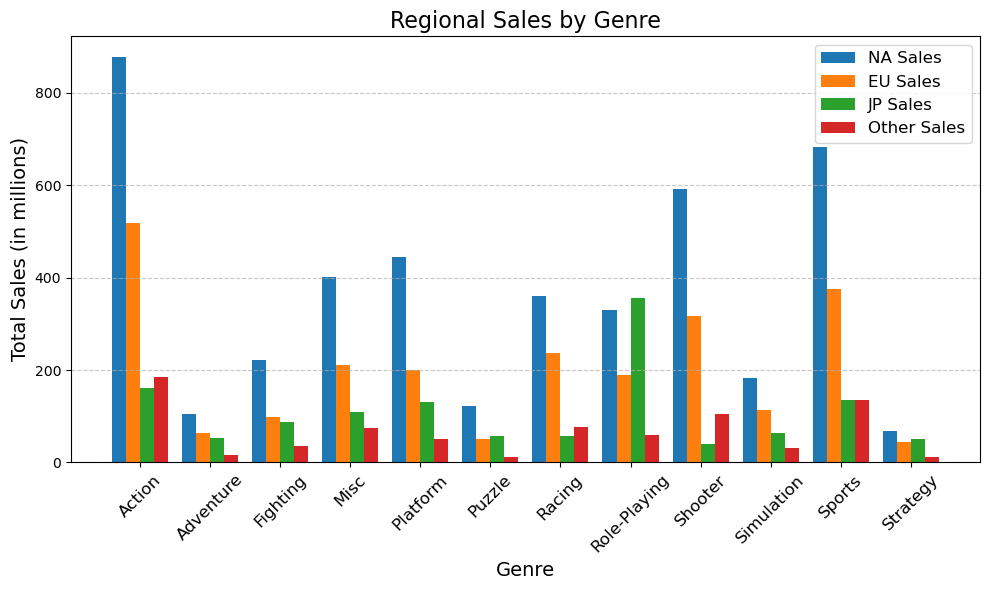

In [183]:
# Group data by Genre and sum up sales for each region
genre_sales = data.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Plotting regional sales by genre
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Set up a grouped bar chart
plt.figure(figsize=(10, 6))
x = range(len(genre_sales))  # Indices for genres

# Width of bars and offsets for each region
bar_width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]  # Positioning the bars for each region

for i, region in enumerate(regions):
    plt.bar(
        [pos + offsets[i] * bar_width for pos in x],  # Offset each bar group
        genre_sales[region],  # Sales data for the region
        width=bar_width,
        label=region.replace('_Sales', ' Sales')  # Better label format
    )

# Add labels, title, and legend
plt.xticks(x, genre_sales.index, rotation=45, fontsize=12)  # Genre names
plt.title('Regional Sales by Genre', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Total Sales (in millions)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

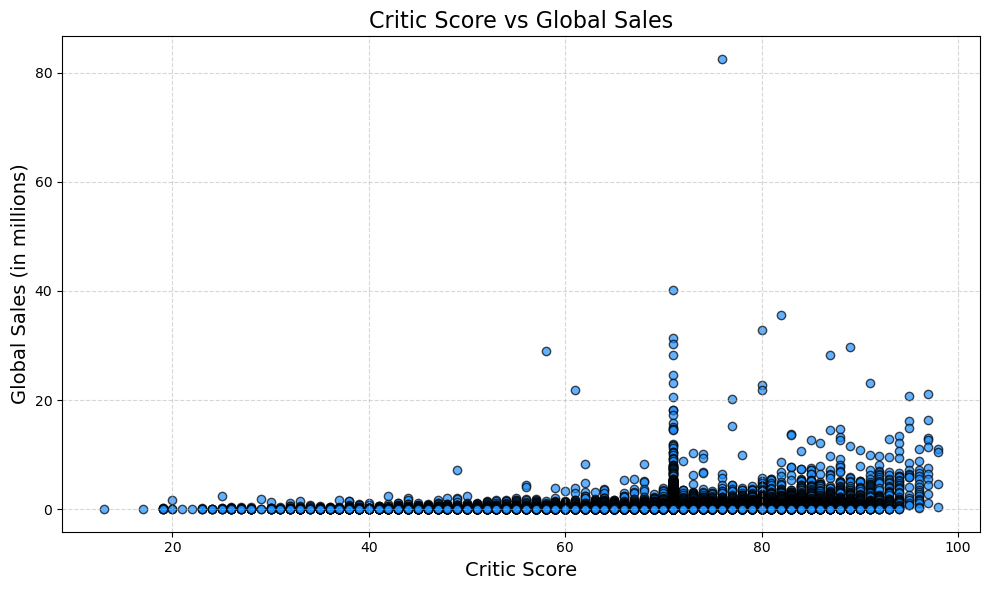

In [184]:
# This is to see the relationship between 'Critic Score' and 'Global Sales'
# Scatter plot for Critic Score vs Global Sales
plt.figure(figsize=(10, 6))

# Plot the data
plt.scatter(
    data['Critic_Score'], 
    data['Global_Sales'], 
    alpha=0.7, 
    color='dodgerblue', 
    edgecolor='black'
)

# Add labels and title
plt.title('Critic Score vs Global Sales', fontsize=16)
plt.xlabel('Critic Score', fontsize=14)
plt.ylabel('Global Sales (in millions)', fontsize=14)

# Add a grid
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Prepare the Data
# One-hot encode 'Genre'
data_one_hot = pd.get_dummies(data, columns=['Genre'], drop_first=True)

# Features: Regional sales, year, critic score, and one-hot encoded genres
features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Year_of_Release', 'Critic_Score'] + [col for col in data_one_hot.columns if 'Genre_' in col]

# Create interaction terms (e.g., Critic_Score * Genre_Action, NA_Sales * Critic_Score)
for feature_1 in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score']:
    for genre in [col for col in features if 'Genre_' in col]:
        data_one_hot[f'{feature_1}*{genre}'] = data_one_hot[feature_1] * data_one_hot[genre]

# Add interaction terms to features
interaction_features = [f'{feature_1}*{genre}' for feature_1 in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score'] for genre in [col for col in features if 'Genre_' in col]]
features += interaction_features

# Target: Global Sales
X = data_one_hot[features]
y = data_one_hot['Global_Sales']

# Step 2: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Evaluate the Model
# Predictions
y_pred = model.predict(X_test)

# Metrics
from sklearn.metrics import mean_squared_error, r2_score
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Root Mean Squared Error (RMSE): 0.01
R² Score: 1.00


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


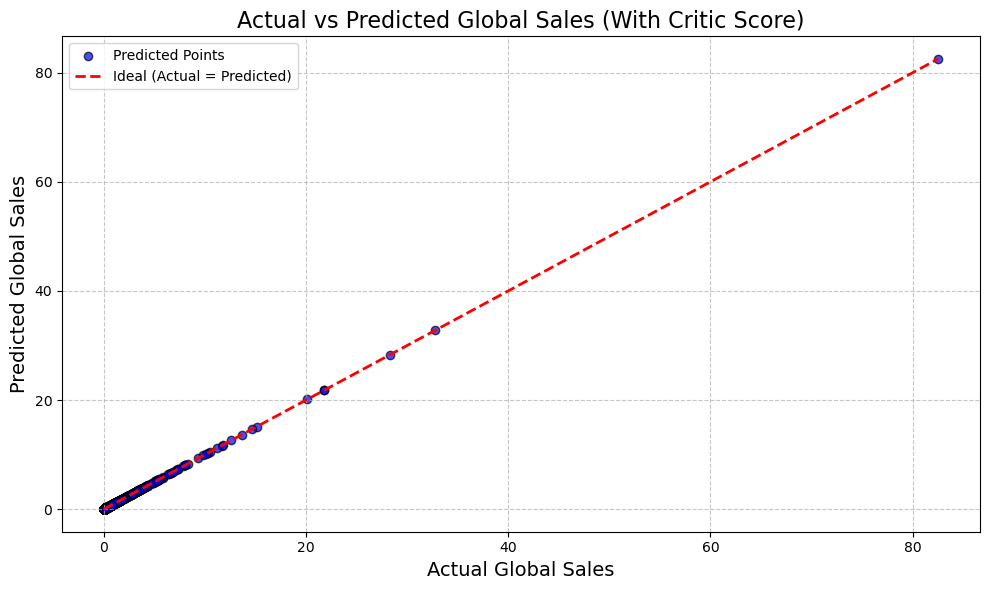

In [186]:
# Visualize Actual vs Predicted Sales: In an ideal visualization, the angle of the graph will be 45 degrees, meaning that the predicted sales matches the actual sales. 
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolor='black', label='Predicted Points')

# Add a diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Ideal (Actual = Predicted)')

# Labels, title, and legend
plt.title('Actual vs Predicted Global Sales (With Critic Score)', fontsize=16)
plt.xlabel('Actual Global Sales', fontsize=14)
plt.ylabel('Predicted Global Sales', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


Model Coefficients:
Intercept: -1.57
Slope (Coefficient for Critic_Score): 0.03


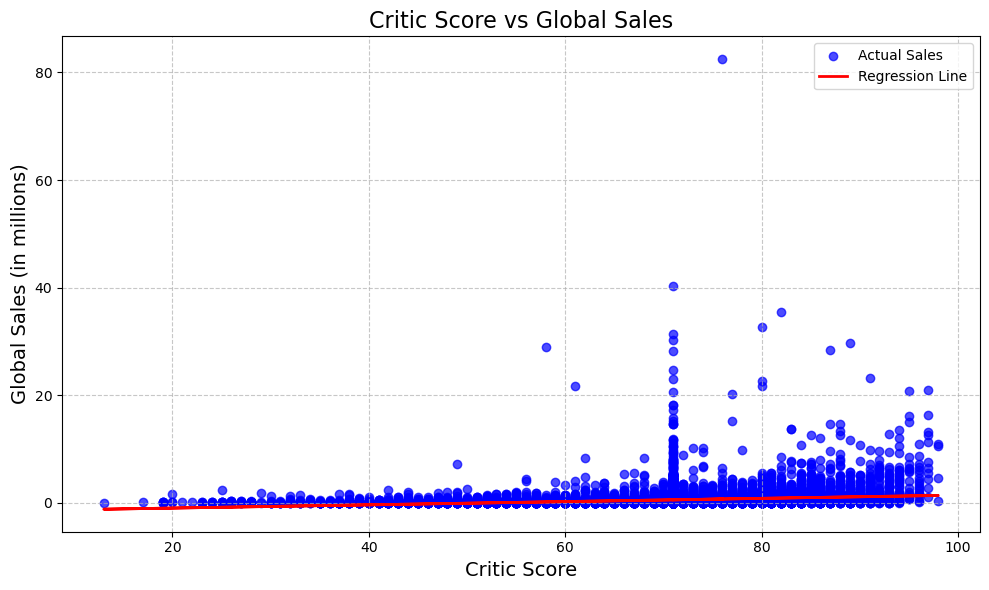

Predicted Global Sales for Critic Score 75: 0.68 million copies.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [187]:
# This is a linear regression model that prompts user to add input(critic score) to output global sales(millions)

# Step 1: Prepare data
# Clean the data of critic score and global sales
data_cleaned = data[['Critic_Score', 'Global_Sales']].dropna()

# Feature (Critic_Score) and target (Global_Sales)
X = data_cleaned[['Critic_Score']] # This has to be two dimensional array
y = data_cleaned['Global_Sales']

# Step 2: Train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print model coefficients
print(f"Model Coefficients:")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope (Coefficient for Critic_Score): {model.coef_[0]:.2f}")

# Step 3: Define function to make predictions
def predict_sales(critic_score):
    if critic_score < 0 or critic_score > 100:
        return "Critic score must be between 0 and 100."
    prediction = model.predict(np.array(critic_score).reshape(-1, 1))
    return f"Predicted Global Sales for Critic Score {critic_score}: {prediction[0]:.2f} million copies."

# Step 4: Visualize data and regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Sales')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title('Critic Score vs Global Sales', fontsize=16)
plt.xlabel('Critic Score', fontsize=14)
plt.ylabel('Global Sales (in millions)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Step 5: Test user inputs
test_input = 75
print(predict_sales(test_input))


# Here we can conclude that Critic Score does affect the Global sales as the outcome and the slope shows a positive correlation.
# The R^2 value indicates how much of the Critic Score influences the outcome. in this case the Global Sales. Here the R^2 value is 1  
# The higher the R squared value, the stronger the correlation is. 
# However, there are some outliers, suggested by the scatter plot, and a high critic score may not necessarily indicate in larger global sales. 
# Critic score may be an important factor, but not the sole reason why the global sales are higher. Other factors such as genre and region might influence it more. 
